### `1.` Numpy array vs Python lists

In [4]:
#speed
#list

a= [i for i in range(10000000)]
b= [i for i in range(10000000,20000000)]
c= []

import time

start = time.time()


for i in range(len(a)):
    c.append(a[i]  + b[i])

print(time.time() - start)

1.2890381813049316


In [3]:
#numpy
import numpy as np

a = np.arange(10000000)
b = np.arange(10000000,20000000)

start = time.time()

c= a + b

print(time.time()-start)

0.02674269676208496


In [ ]:
# memory
#python list
a= [i for i in range(10000000)]
import sys

sys.getsizeof(a)

89095160

In [8]:
#numpy array

a = np.arange(10000000, dtype = np.int32)
sys.getsizeof(a)

40000112

### `2.` Advanced Indexing

In [10]:
# normal Indexing and slicing 

a = np.arange(12).reshape(4,3)

print(a[1,2])

print(a[1:3,1:3])


5
[[4 5]
 [7 8]]


In [12]:
# fancy indexing

print(a)

a[[0,2,3]]

[[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]]


array([[ 0,  1,  2],
       [ 6,  7,  8],
       [ 9, 10, 11]])

In [19]:
 b=np.arange(24).reshape(6,4)
 
 b [:,[0,2,3]]

array([[ 0,  2,  3],
       [ 4,  6,  7],
       [ 8, 10, 11],
       [12, 14, 15],
       [16, 18, 19],
       [20, 22, 23]])

In [22]:
# Boolean Indexing

import numpy as np

a = np.random.randint(1,100,24).reshape(6,4)
a

array([[63,  3, 48, 66],
       [57, 64, 10, 99],
       [ 4, 32, 92, 80],
       [ 6, 26, 69, 60],
       [77, 11, 33, 76],
       [14, 64, 89, 52]], dtype=int32)

In [24]:
# find all numbers greater than 50
a[a>50]

array([63, 66, 57, 64, 99, 92, 80, 69, 60, 77, 76, 64, 89, 52],
      dtype=int32)

In [32]:
# find all numbers greater than 50 and are even

a[(a>50) & (a%2 == 0)]

array([66, 64, 92, 80, 60, 76, 64, 52], dtype=int32)

In [30]:
# find all the numbers divisible by 7

a[~(a%7 == 0)]

array([ 3, 48, 66, 57, 64, 10, 99,  4, 32, 92, 80,  6, 26, 69, 60, 11, 33,
       76, 64, 89, 52], dtype=int32)

## `3.` Broadcasting

- it describes how numpy treats arrays with different shapes during arithemetic operations

- The smaller array is "broadcast" across the larger array so that they have compatible shapes

In [36]:
#same shape

a = np.arange(6).reshape(2,3)
b = np.arange(6,12).reshape(2,3)
print(a)
print(b)

print(a+b)

[[0 1 2]
 [3 4 5]]
[[ 6  7  8]
 [ 9 10 11]]
[[ 6  8 10]
 [12 14 16]]


In [37]:
#different shapes
a = np.arange(6).reshape(2,3)
b = np.arange(3).reshape(1,3)
print(a)
print(b)

print(a+b)


[[0 1 2]
 [3 4 5]]
[[0 1 2]]
[[0 2 4]
 [3 5 7]]


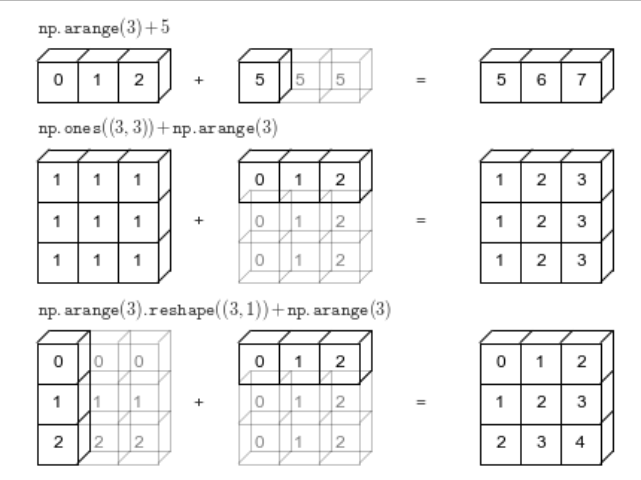
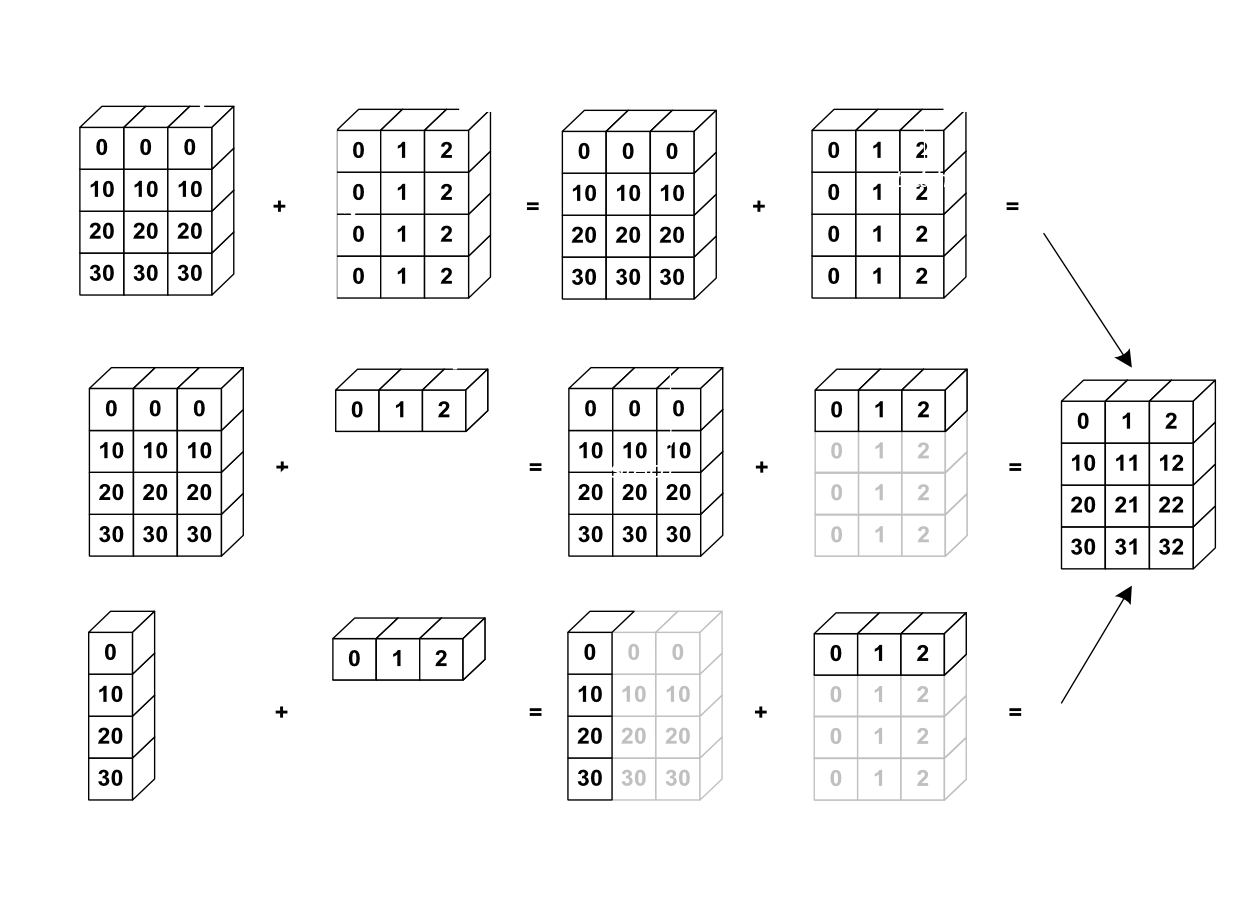

Rules

1. make both arrays of same dimensions 
    - if dimension of 2 arrays are different, add new dimension of size 1 to the head of array with smaller dimension.

    eg: (3,3) and (3, )
        (3,3) and (1,3)

2. Make each dimension of both array same
    - If the dimension of two arrays do not match , dimension with size 1 are stretched to the size of other array

    eg: (3,3) and (1,3)
        (3,3) and (3,3)

    - if there is a dimension whose size is not 1 in either of two arrays, it cannot be broadcasted and an error is raised.

In [ ]:
# Example 1

a =  np.arange(12).reshape(4,3)  #(4,3)
b = np.arange(3)                 #(3,) -> (1,3) -> (4,3)
                                # broadcasting possible

print(a)
print(b)
print(a+b)


[[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]]
[0 1 2]
[[ 0  2  4]
 [ 3  5  7]
 [ 6  8 10]
 [ 9 11 13]]


In [ ]:
# Example 2

a =  np.arange(12).reshape(3,4)    # (3,4)
b = np.arange(3)                    # (3,) -> (1,3), (3,3)
                                    # not possible

print(a)
print(b)
print(a+b)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
[0 1 2]


ValueError: operands could not be broadcast together with shapes (3,4) (3,) 

In [ ]:
#Example 3
a = np.arange(3).reshape(1,3)  # (1,3) -> (3,3)
b = np.arange(3).reshape(3,1)   #(3,1) -> (3,3)

print(a)
print(b)
print(a+b)

[[0 1 2]]
[[0]
 [1]
 [2]]
[[0 1 2]
 [1 2 3]
 [2 3 4]]


In [ ]:
# Example 4
a = np.arange(3).reshape(1,3)  # (1,3) -> (4,3)
b = np.arange(4).reshape(4,1)   #(4,1) -> (4,3)

print(a)
print(b)
print(a+b)


[[0 1 2]]
[[0]
 [1]
 [2]
 [3]]
[[0 1 2]
 [1 2 3]
 [2 3 4]
 [3 4 5]]


In [45]:
# Example 5

a = np.array([1])               # (1,) -> (1,1) -> (2,2)

b = np.arange(4).reshape(2,2)    #(2,2)

print(a)
print(b)

print(a+b)


[1]
[[0 1]
 [2 3]]
[[1 2]
 [3 4]]


In [ ]:
# Example 6

a =  np.arange(12).reshape(3,4)  # -> no 1 -> cant be streched
b = np.arange(12).reshape(4,3)    # -> no 1

print(a)
print(b)
print(a+b)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
[[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]]


ValueError: operands could not be broadcast together with shapes (3,4) (4,3) 

In [ ]:
# Example 7
# -> same as above no 1 so not strechable
a = np.arange(16).reshape(4,4)

b= np.arange(4).reshape(2,2)

print(a)
print(b)

print(a+b)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]]
[[0 1]
 [2 3]]


ValueError: operands could not be broadcast together with shapes (4,4) (2,2) 

## `4.` Working with mathematical formula

In [51]:
 # sigmoid

def sigmoid(a):
    return 1/(1+np.exp(-(a)))

a = np.arange(10)
sigmoid(a)

array([0.5       , 0.73105858, 0.88079708, 0.95257413, 0.98201379,
       0.99330715, 0.99752738, 0.99908895, 0.99966465, 0.99987661])

In [52]:
# mean squared error

actual  = np.random.randint(1,50,25)
predicted = np.random.randint(1,50,25)

In [53]:
print(actual)

[12 11 36 29 16 46 40 20 20 26  7  5 31 44 39 10 30 36 34 34 49 41 27 12
 29]


In [54]:
print(predicted)

[ 6  6  8 34  9 10 45 34 40  9 15  7 19  8 14 12  8 17 48 17 29 32 48 38
 22]


In [56]:
def mse(actual,predicted):
    return np.mean((actual - predicted)**2)

mse(actual, predicted)


np.float64(329.56)

### `5.` Working with missing values

In [66]:
#Working with missing values -> np.nan

a = np.array([1,2,3,4,np.nan,6])
a[~np.isnan(a)]

array([1., 2., 3., 4., 6.])

## `6.` Plotting graph

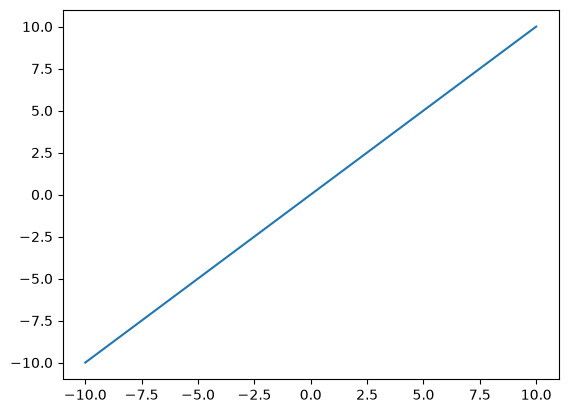

In [71]:
# plotting a 2D plot
#x = y
import matplotlib.pyplot as plt
x = np.linspace(-10,10)
y = x

plt.plot(x,y)

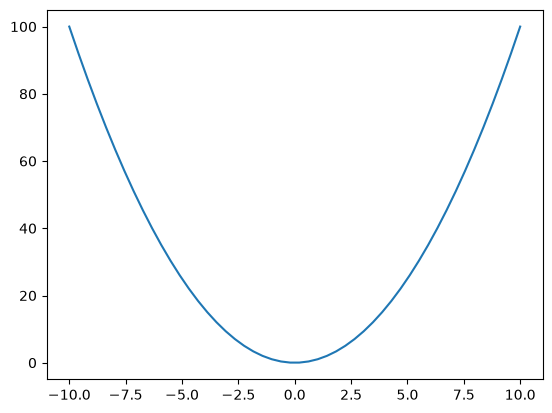

In [72]:
#y = x^2

x = np.linspace(-10,10)
y = x**2

plt.plot(x,y)

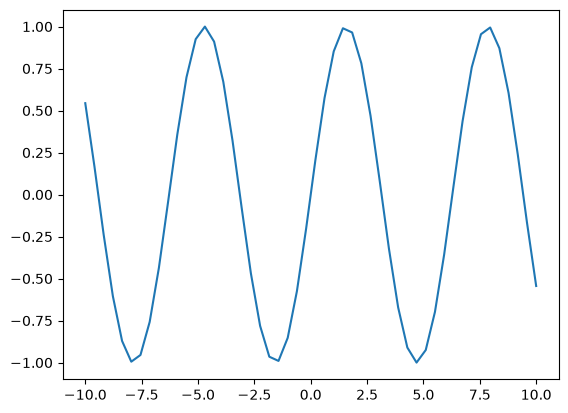

In [73]:
# y = sin(x)

x = np.linspace(-10,10)
y = np.sin(x)

plt.plot(x,y)

C:\Users\lokes\AppData\Local\Temp\ipykernel_22036\646304511.py:4: RuntimeWarning: invalid value encountered in log
  y = x*np.log(x)


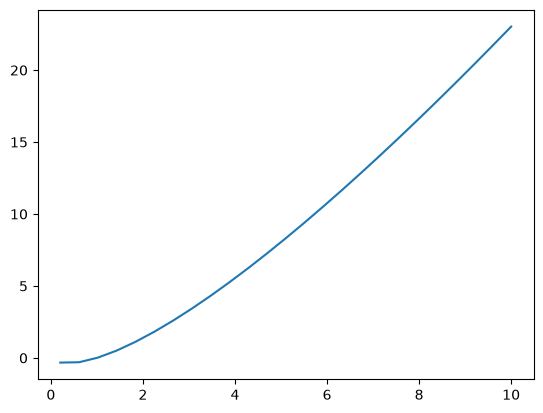

In [74]:
# y = xlog(x)

x = np.linspace(-10,10)
y = x*np.log(x)

plt.plot(x,y)

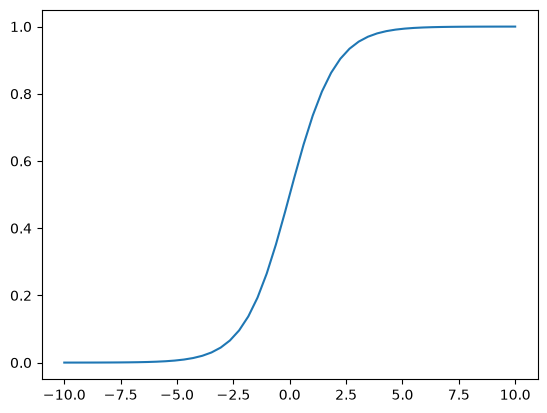

In [78]:
#sigmoid
x = np.linspace(-10,10)
y = 1/(1+np.exp(-x))

plt.plot(x,y)

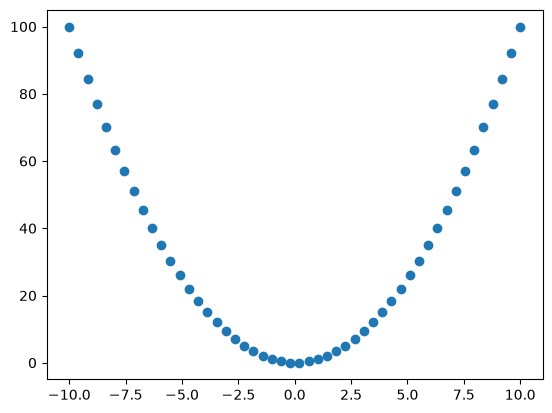

In [76]:
# plotting scatter plot

x = np.linspace(-10,10)
y = x**2

plt.scatter(x,y)